In [1]:
import sys

from pathlib import Path
root = Path.cwd()
while not (root / "Models").is_dir():
    root = root.parent
sys.path.insert(0, str(root))

from config import *

from Models.Papers.Battaglia2012 import Battaglia2012

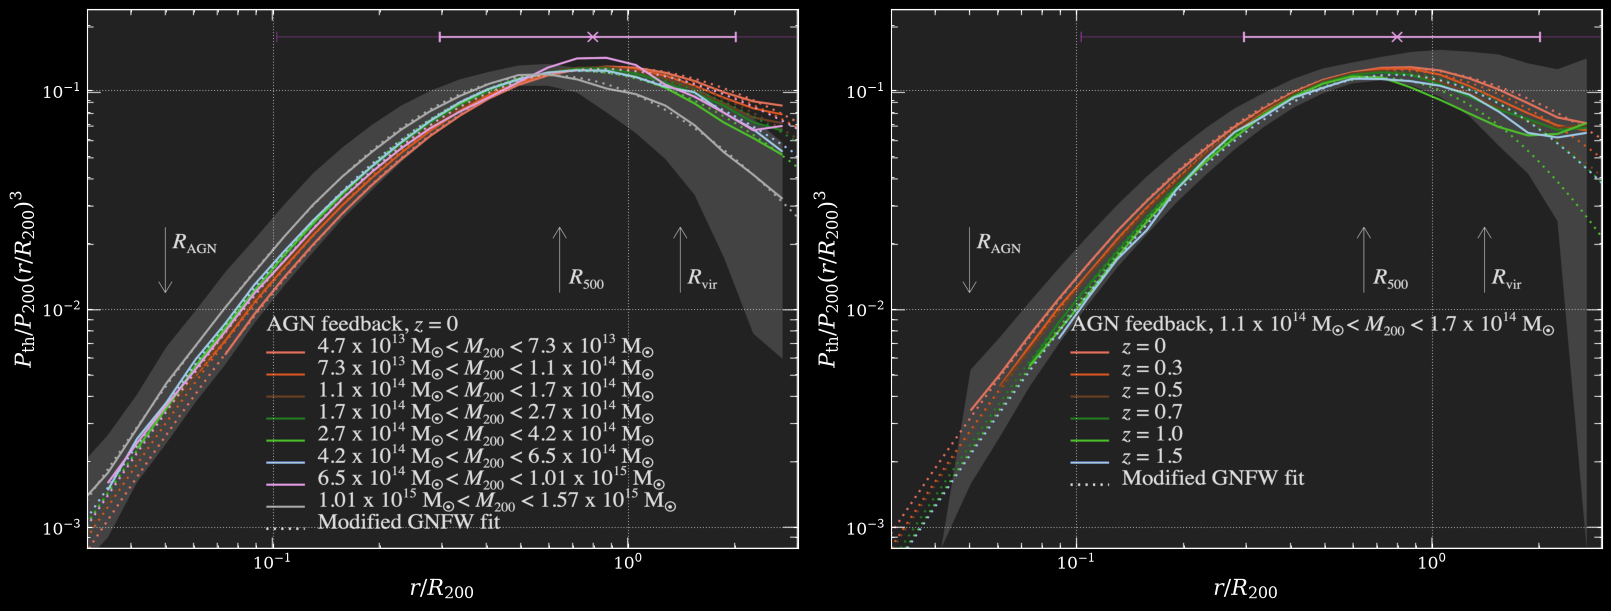

In [3]:
importlib.reload(Battaglia2012)
fig, axs = Battaglia2012.Fig1().full()

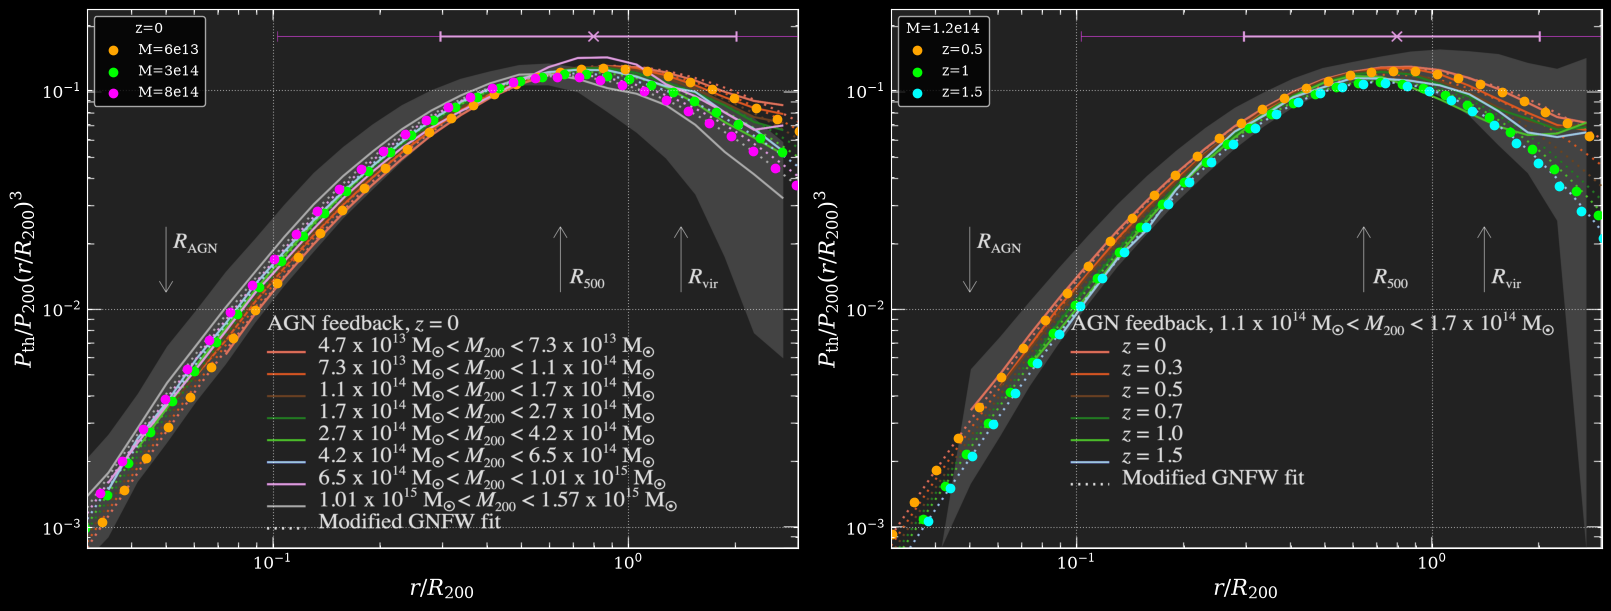

In [4]:
importlib.reload(Battaglia2012)
fig, axs = Battaglia2012.Fig2().full()


from Models import HaloModels, Profiles
importlib.reload(HaloModels); importlib.reload(Profiles)

hmod = HaloModels.pyccl_model(Profiles.Battaglia2011().info)
r = np.geomspace(1e-2, 1e1, 50)
z, logM200c = 0, np.log10(1.2e14)
x = lambda z, logM200c: r*u.Mpc/hmod.rdel('200c')(z, logM200c)

B11 = Profiles.Battaglia2011(rhoc=hmod.rhoc, r200c=hmod.rdel('200c'))
pfunc = lambda z, logM200c: (B11.Pressure(r, z, logM200c)()/B11.P200c(z, logM200c))[:, 0, 0]*x(z, logM200c)**3

axs[0].scatter(x(z, np.log10(6e13)), pfunc(z, np.log10(6e13)), c='orange', label='M=6e13')
axs[0].scatter(x(z, np.log10(3e14)), pfunc(z, np.log10(3e14)), c='lime', label='M=3e14')
axs[0].scatter(x(z, np.log10(8e14)), pfunc(z, np.log10(8e14)), c='magenta', label='M=8e14')

axs[1].scatter(x(0, logM200c), pfunc(0, logM200c), c='orange', label='z=0.5')
axs[1].scatter(x(1, logM200c), pfunc(1, logM200c), c='lime', label='z=1')
axs[1].scatter(x(1.5, logM200c), pfunc(1.5, logM200c), c='cyan', label='z=1.5')

axs[0].legend(title='z=0'); axs[1].legend(title='M=1.2e14')
plt.show()